In [2]:
import math

In [ ]:
class Value:

    def __init__(self,data, _children = (),_op="", label = ""):
        self.data = data 
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label


    def __repr__(self):
        return f"Value = {self.data}"

    def __add__(self,other):
        out = Value(self.data + other.data, (self,other), "+")
        def backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = backward
        return out
    
    def __mul__(self,other):
        out = Value(self.data * other.data, (self,other), "*")

        def backward():
            self.grad += other.data * out.grad
            other.grad +=self.data * out.grad
        out._backward = backward
        
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x)+1)
        out =  Value(t,(self, ),"tanh")

        def backward():
            self.grad = (1-t**2) * out.grad   
                     
        out._backward = backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()            
a = Value(7, label = "a")
b = Value(6, label = "b")
c = Value(-10, label = "c")
e = a*b; e.label = "e"
d = e+ c; d.label = "d"
L = d * e ; L.label = "L"
L


d

Value = 32

In [4]:
d._prev

{Value = -10, Value = 42}

out = Value(30, (a, b))
now we get 30 as data, and a and b as children becasue init(data,children)

In [5]:
d._op


'+'

In [6]:
from graphviz import Digraph
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data,n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


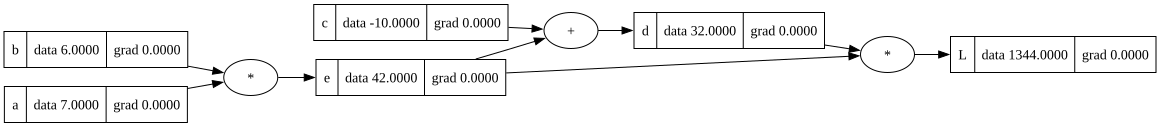

In [7]:
draw_dot(L)

In [8]:
L.grad = 1

In [9]:
def lol():
    h = 0.000001
    a = Value(7, label = "a")
    b = Value(6, label = "b")
    c = Value(-10, label = "c")
    e = a*b; e.label = "e"
    d = e+ c; d.label = "d"
    L = d * e ; L.label = "L"
    L1 = L.data

    a = Value(7 + h, label = "a")
    b = Value(6, label = "b")
    c = Value(-10, label = "c")
    e = a*b; e.label = "e"
    d = e+ c; d.label = "d"
    L = d * e ; L.label = "L"
    L2 = L.data

    print((L2 - L1)/h)
lol()


444.00003594091686


In [10]:
d.grad = e.data

In [11]:
e.grad = d.data

In [12]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.88137, label='b')
#x1w1 + x2w2 + b

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh() ;o.label = "o"

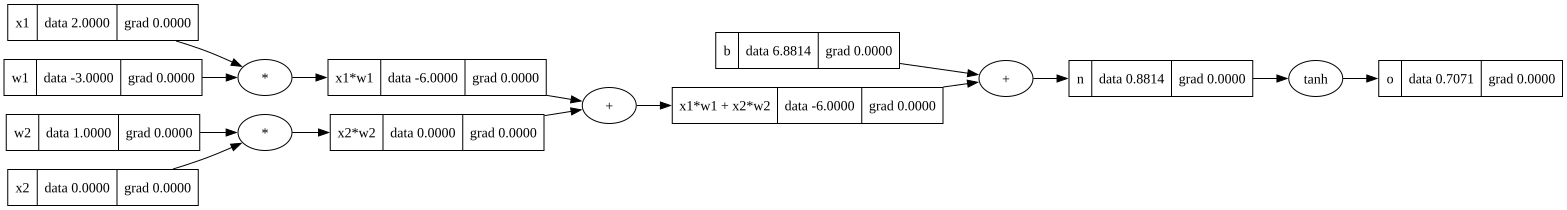

In [13]:

draw_dot(o)

In [14]:
o.grad = 1
o.data

0.7071049876722272

In [15]:
1-o.data**2

0.5000025364090595

In [16]:
n.grad = 0.5

In [17]:
 # TOPOLOGICAL SORT

In [18]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value = 6.88137,
 Value = 0.0,
 Value = 1.0,
 Value = 0.0,
 Value = 2.0,
 Value = -3.0,
 Value = -6.0,
 Value = -6.0,
 Value = 0.8813700000000004,
 Value = 0.7071049876722272]

In [19]:
for node in reversed(topo):
    node._backward()